# Lab 10
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.

In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


ensure_module('numpy', ['numpy<2'])
ensure_module('matplotlib', ['matplotlib'])
ensure_module('PIL', ['Pillow'])
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')

numpy already available.


matplotlib already available.
PIL already available.


cv2 already available.


skimage already available.
Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

%matplotlib inline


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Task 1: Canny Edge Detection
An **edge** is where brightness changes sharply. Canny (1986) finds edges in 5 steps: Gaussian blur, gradients, non-maximum suppression (thin the edges), double thresholding, and hysteresis (keep weak edges only if they connect to strong ones).

`cv2.Canny(img, T_low, T_high)`:
- `T_low` = lower threshold (weak edges)
- `T_high` = upper threshold (strong edges)
- Rule of thumb: `T_high ≈ 2×T_low` or `3×T_low`.

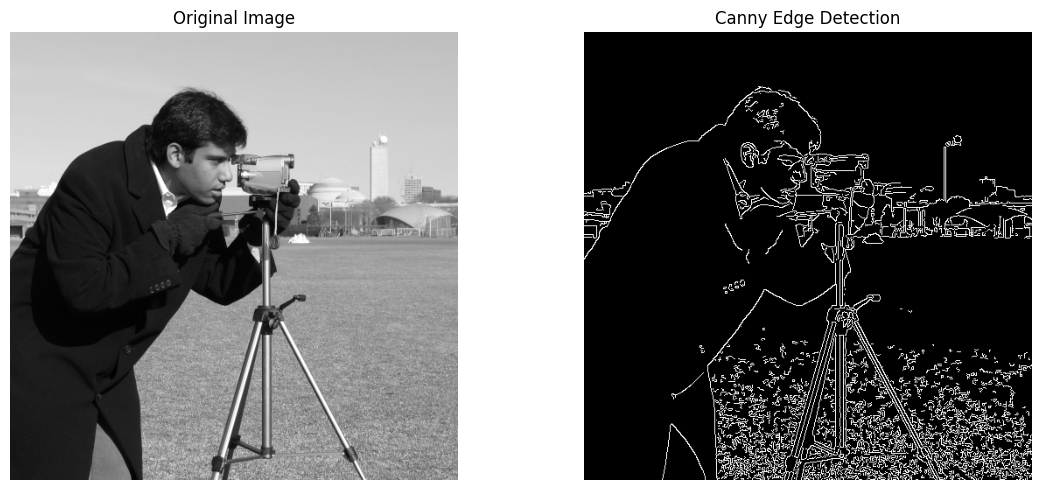

In [3]:
img = data.camera()

edges = cv2.Canny(img, 100, 200)

show_images(
    [img, edges],
    ['Original Image', 'Canny Edge Detection'],
    figsize=(12, 5)
)

### Task 2: Harris Corner Detection
A **corner** is a point where the image changes in *two* different directions, making corners highly distinctive for matching, tracking, and camera calibration.

Parameters: `blockSize` (window size), `ksize` (Sobel kernel size), `k` (sensitivity, typically 0.04–0.06).

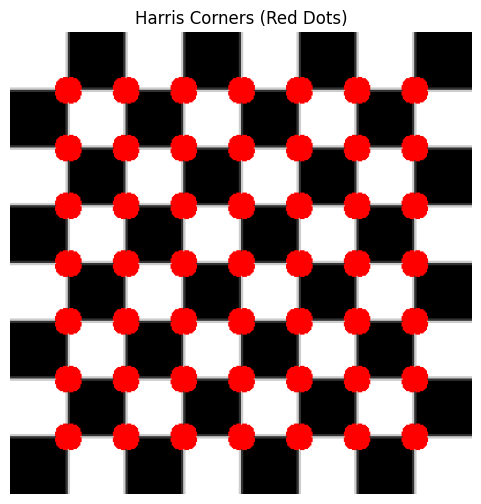

In [4]:
board = data.checkerboard()
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners (Red Dots)')
plt.axis('off')
plt.show()

### Simple (Global) Binary Thresholding
The most basic segmentation: pick a fixed threshold `T` and turn every pixel above it white, below it black.

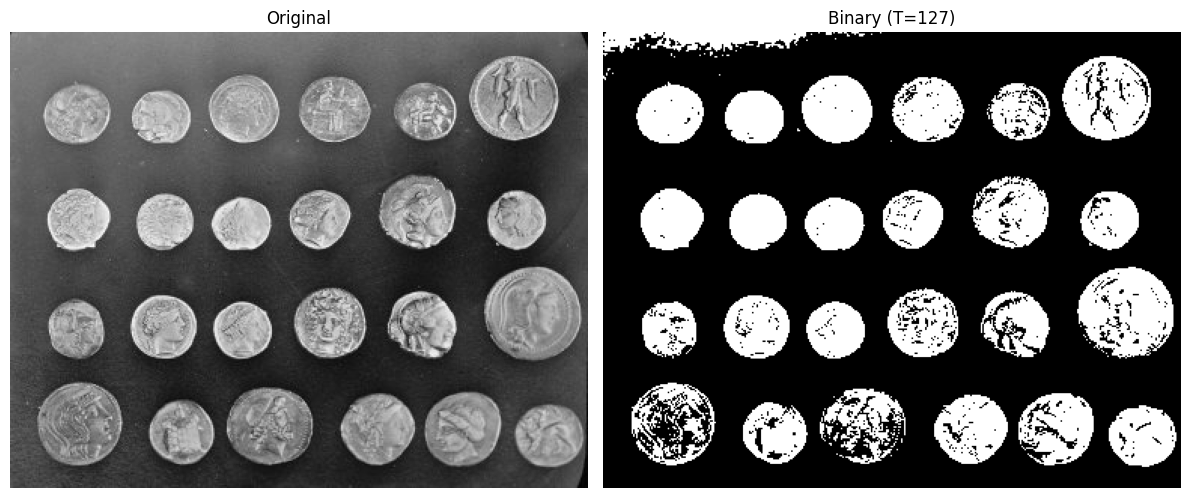

In [5]:
img = data.coins()

T = 127
_, binary = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

show_images(
    [img, binary],
    ['Original', f'Binary (T={T})'],
    figsize=(12, 5)
)

## Assessment Tasks

### Q1 — Otsu's Thresholding
Otsu picks the threshold `T` **automatically** by maximizing the between-class variance — assumes the histogram has two peaks (foreground + background).

Show the original image, its histogram with the Otsu threshold marked, and the thresholded result.

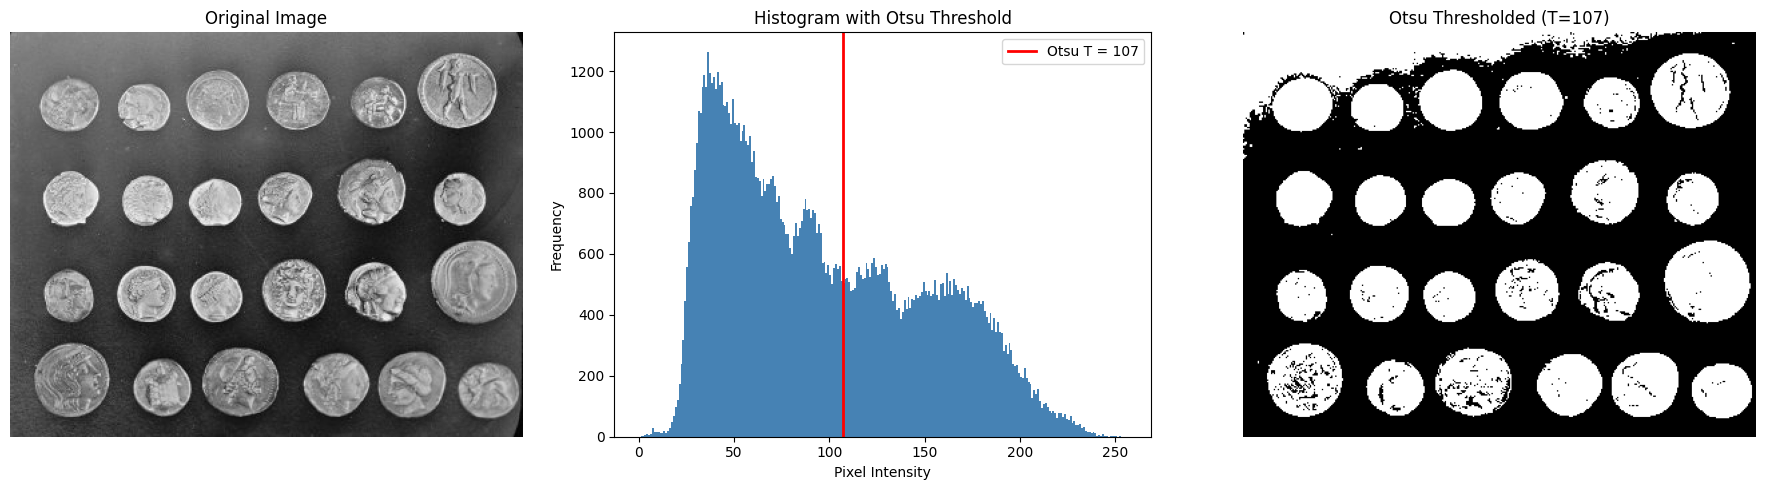

In [6]:
img = data.coins()

otsu_thresh, binary_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(img.ravel(), bins=256, range=(0, 256), color='steelblue', edgecolor='none')
axes[1].axvline(x=otsu_thresh, color='red', linewidth=2, label=f'Otsu T = {int(otsu_thresh)}')
axes[1].set_title('Histogram with Otsu Threshold')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].imshow(binary_otsu, cmap='gray')
axes[2].set_title(f'Otsu Thresholded (T={int(otsu_thresh)})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## Summary Table

| Technique | Category | What it finds | OpenCV function |
|---|---|---|---|
| Canny | Edge detection | Thin connected edges | `cv2.Canny` |
| Sobel | Edge detection | Gradient magnitude (thick) | `cv2.Sobel` |
| Laplacian | Edge detection | Zero-crossings (2nd deriv) | `cv2.Laplacian` |
| Harris | Feature extraction | Corners | `cv2.cornerHarris` |
| Shi-Tomasi | Feature extraction | Corners (improved) | `cv2.goodFeaturesToTrack` |
| Simple threshold | Segmentation | Fixed-`T` binary mask | `cv2.threshold` |
| Otsu | Segmentation | Auto bimodal threshold | `cv2.threshold` + `THRESH_OTSU` |
| Adaptive threshold | Segmentation | Local-`T` binary mask | `cv2.adaptiveThreshold` |